# R07 - Fidelity Estimators

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Comparar `ConservativeMinEstimator` e `SequenceConsistentEstimator` com
dados reais da campanha final `F07_estimators` (diamante, 3 estratégias
x 2 estimadores x 20 seeds). Ver `docs/fidelity_estimation_model.md`.
Não roda simulação - carrega apenas dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência

In [2]:
CAMPAIGN = "F07_estimators"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"] == 120
assert set(trials_df["fidelity_estimator"].unique()) == {"conservative_min", "sequence_consistent"}
trials_df.head(3)

,campaign,trial_id,scenario,parameter_hash,seed,intent_id,routing_strategy,purification_policy,reconciliation_enabled,route,...,ep_success,es_attempts,es_success,violations,error_type,error_message,project_git_commit,sequence_git_commit,python_version,timestamp
0,F07_estimators,F07_estimators:diamond_heterogeneous:c9582aba4...,diamond_heterogeneous,c9582aba463e52f3,0,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=4.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:41:42.949600+00:00
1,F07_estimators,F07_estimators:diamond_heterogeneous:c9582aba4...,diamond_heterogeneous,c9582aba463e52f3,1,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=8.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:41:44.837589+00:00
2,F07_estimators,F07_estimators:diamond_heterogeneous:c9582aba4...,diamond_heterogeneous,c9582aba463e52f3,2,intent-diamond-demo,shortest_hop_count,automatic,False,r1 -> bad -> r3,...,0,0,0,delivered_pairs >= 10.0 (observed=7.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:41:46.741227+00:00


## Erro absoluto de fidelidade por estimador (n, média, IC95%)

In [3]:
summary = aggregate_records(trials_df, group_by=["fidelity_estimator"], metrics=["absolute_fidelity_error"])
save_table(summary, "R07_summary", directory=TABLES_OUT)
summary[["fidelity_estimator", "metric", "n_valid", "mean", "std", "ci95_low", "ci95_high"]]

,fidelity_estimator,metric,n_valid,mean,std,ci95_low,ci95_high
0,conservative_min,absolute_fidelity_error,60,7.314697e-02,1.423015e-02,6.947093e-02,7.682301e-02
1,sequence_consistent,absolute_fidelity_error,60,-5.551115e-18,2.440095e-17,-1.185455e-17,7.523175e-19


## Comparações estatísticas pareadas

In [4]:
stats_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "statistical_comparisons.csv")
significant = stats_df[stats_df["p_value_holm_adjusted"] < 0.05]
print(f"{len(significant)}/{len(stats_df)} comparisons significant after Holm correction")
significant[["scenario", "routing_strategy", "value_col", "n", "mean_a", "mean_b", "test_used", "p_value_holm_adjusted", "effect_size"]]

3/15 comparisons significant after Holm correction


,scenario,routing_strategy,value_col,n,mean_a,mean_b,test_used,p_value_holm_adjusted,effect_size
4,diamond_heterogeneous,highest_fidelity,absolute_fidelity_error,20,0.083125,0.000000e+00,wilcoxon,0.000008,-1.0
9,diamond_heterogeneous,least_loss,absolute_fidelity_error,20,0.053191,-1.665335e-17,wilcoxon,0.000023,-1.0
14,diamond_heterogeneous,shortest_hop_count,absolute_fidelity_error,20,0.083125,0.000000e+00,wilcoxon,0.000008,-1.0


## Figura

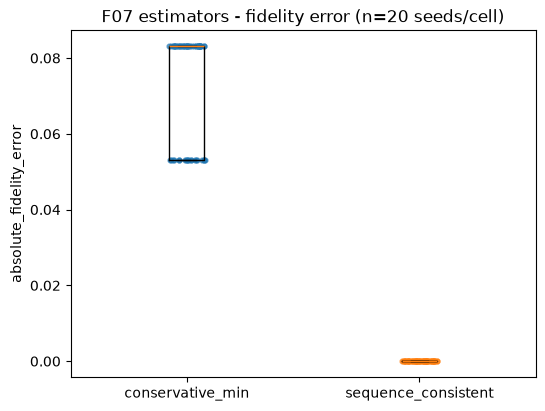

In [5]:
estimators = sorted(trials_df["fidelity_estimator"].unique())
fig, ax = plt.subplots(figsize=(6, 4.5))
groups = [trials_df[trials_df["fidelity_estimator"] == e]["absolute_fidelity_error"].to_numpy() for e in estimators]
ax.boxplot(groups, tick_labels=estimators, showfliers=False)
for i, g in enumerate(groups, start=1):
    ax.scatter(np.full(len(g), i) + np.random.default_rng(i).uniform(-0.08, 0.08, len(g)), g, s=12, alpha=0.6)
ax.set_ylabel("absolute_fidelity_error")
ax.set_title(f"F07 estimators - fidelity error (n={trials_df['seed'].nunique()} seeds/cell)")
save_figure(fig, "R07_fidelity_error", directory=FIGURES_OUT)
plt.show()

## Conclusão

`SequenceConsistentEstimator` reproduz o modelo de fidelidade
implementado pelo SeQUeNCe nas configurações avaliadas (erro
numericamente zero) - nunca "predicts perfectly in real networks"
(`docs/fidelity_estimation_model.md`,
`docs/core_contribution_statement.md`).

## Limitações

`SequenceConsistentEstimator` reproduz o modelo do SeQUeNCe nas configurações avaliadas - não é uma alegação sobre precisão física real nem sobre topologias fora do catálogo testado.